<a href="https://colab.research.google.com/github/dachshoon/Deeplearning_project1/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3

## Load the Data and Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")
%matplotlib inline

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 12, 8

In [ ]:
import io
from google.colab import files

uploaded = files.upload()
data = pd.read_csv("data.csv", index_col="t") # t를 index로
display(data.head()) # data의 맨 앞 5개 출력

Saving data.csv to data (8).csv


,x1,x2
t,,
0,34.623660,78.024693
0,30.286711,43.894998
0,35.847409,72.902198
1,60.182599,86.308552
1,79.032736,75.344376


In [ ]:
feature = data[["x1", "x2"]].values
class_label = data.index.values.reshape(-1,1)
print("feature shape:", feature.shape)
print("class shape:", class_label.shape)

feature shape: (100, 2)
class shape: (100, 1)


## Split Data

In [ ]:
mean_scores = np.mean(feature, axis=0)
std_scores = np.std(feature, axis=0)
X_scaled = (feature - mean_scores) / std_scores

y = class_label

split_idx = int(len(X_scaled) * 0.8) #8:2로 split

X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 2)
y_train shape: (80, 1)
X_test shape: (20, 2)
y_test shape: (20, 1)


## Activation function

In [ ]:
def relu(x):
  return np.maximum(0, x)

def relu_derivative(x):
  return np.where(x > 0, 1, 0)

def tanh(x):
  return np.tanh(x)

def tanh_derivative(x):
  return 1 - np.tanh(x) ** 2

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

## Forward Propagation

In [ ]:
import numpy as np

def initialize_parameters_deep(layer_dims, init_way="default"):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)

    for l in range(1, L):
        n_in = layer_dims[l-1]
        n_out = layer_dims[l]

        if init_way == "He":
            std = np.sqrt(2.0 / n_in)
        elif init_way == "Xavier":
            std = np.sqrt(2.0 / (n_in + n_out))
        elif init_way == "LeCun":
            std = np.sqrt(1.0 / n_in)
        else:
            std = 0.1

        parameters['W' + str(l)] = np.random.randn(n_in, n_out) * std
        parameters['b' + str(l)] = np.zeros((1, n_out))

        print(f"[{init_way} Init] Layer {l}: W{l} shape {parameters['W'+str(l)].shape}, std used: {std:.4f}")

    return parameters

def forward_propagation_deep(X, parameters, activation="relu"):
    caches = {}
    caches['A0'] = X
    L = len(parameters) // 2

    for l in range(1, L):
        A_prev = caches['A' + str(l-1)]
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]

        Z = np.dot(A_prev, W) + b

        if activation == "relu":
            A = relu(Z)
        elif activation == "tanh":
            A = tanh(Z)

        caches['Z' + str(l)] = Z
        caches['A' + str(l)] = A

    W_last = parameters['W' + str(L)]
    b_last = parameters['b' + str(L)]

    ZL = np.dot(caches['A' + str(L-1)], W_last) + b_last
    AL = sigmoid(ZL)
    caches['Z' + str(L)] = ZL
    caches['A' + str(L)] = AL

    return AL, caches

## Back Propagation

In [ ]:
def backward_propagation_deep(AL, Y, caches, parameters, activation="relu"):
    grads = {}
    L = len(parameters) // 2
    m = AL.shape[0]

    dZL = AL - Y
    A_prev = caches['A' + str(L-1)]

    grads["dW" + str(L)] = (1.0 / m) * np.dot(A_prev.T, dZL)
    grads["db" + str(L)] = (1.0 / m) * np.sum(dZL, axis=0, keepdims=True)

    dA_prev = np.dot(dZL, parameters['W' + str(L)].T)

    for l in reversed(range(1, L)):
        Z_curr = caches['Z' + str(l)]
        A_prev = caches['A' + str(l-1)]
        W_curr = parameters['W' + str(l)]

        if activation == "relu":
            dZ_curr = dA_prev * relu_derivative(Z_curr)
        elif activation == "tanh":
            dZ_curr = dA_prev * tanh_derivative(Z_curr)

        grads["dW" + str(l)] = (1.0 / m) * np.dot(A_prev.T, dZ_curr)
        grads["db" + str(l)] = (1.0 / m) * np.sum(dZ_curr, axis=0, keepdims=True)

        dA_prev = np.dot(dZ_curr, W_curr.T)

    return grads

In [ ]:
layer_dims = [X_train.shape[1], 8, 4, 1]

params_deep = initialize_parameters_deep(layer_dims)

AL, caches = forward_propagation_deep(X_train, params_deep, activation="relu")

grads_deep = backward_propagation_deep(AL, y_train, caches, params_deep, activation="relu")

print("계산된 기울기 목록(Keys):", grads_deep.keys())


[default Init] Layer 1: W1 shape (2, 8), std used: 0.1000
[default Init] Layer 2: W2 shape (8, 4), std used: 0.1000
[default Init] Layer 3: W3 shape (4, 1), std used: 0.1000
계산된 기울기 목록(Keys): dict_keys(['dW3', 'db3', 'dW2', 'db2', 'dW1', 'db1'])


## Update Parameters and training

In [ ]:
def compute_loss(A2, Y):
    m = Y.shape[0]

    epsilon = 1e-15
    A2 = np.clip(A2, epsilon, 1 - epsilon)

    loss = - (1 / m) * np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))

    return loss

In [ ]:
def update_parameters_deep(parameters, grads, learning_rate):
    L = len(parameters) // 2

    for l in range(1, L + 1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    return parameters

def predict_deep(X, parameters, activation="relu"):
    AL, _ = forward_propagation_deep(X, parameters, activation)
    predictions = (AL >= 0.5).astype(int)
    return predictions

def get_accuracy(predictions, Y):
    return np.mean(predictions == Y) * 100

def train_deep_model(X_train, y_train, X_test, y_test, layer_dims, epochs=2000, learning_rate=0.5, activation="relu", init_way="default"):
    np.random.seed(42)

    print(f"layer 구조: {layer_dims}, 초기화 방식: {init_way} ")

    parameters = initialize_parameters_deep(layer_dims, init_way=init_way)

    train_losses = []

    for i in range(epochs):
        AL, caches = forward_propagation_deep(X_train, parameters, activation)
        loss = compute_loss(AL, y_train)
        grads = backward_propagation_deep(AL, y_train, caches, parameters, activation)
        parameters = update_parameters_deep(parameters, grads, learning_rate)

        train_losses.append(loss)

        if i % 1000 == 0:
            train_acc = get_accuracy(predict_deep(X_train, parameters, activation), y_train)
            print(f"Epoch {i:4d} | Loss: {loss:.4f} | Train Acc: {train_acc:.1f}%")

    test_predictions = predict_deep(X_test, parameters, activation)
    test_acc = get_accuracy(test_predictions, y_test)
    print(f"\n최종 Test Accuracy: {test_acc:.2f}%")

    return parameters, train_losses, test_acc

실험 1 : 은닉층 1개
layer 구조: [2, 8, 1], 초기화 방식: default 
[default Init] Layer 1: W1 shape (2, 8), std used: 0.1000
[default Init] Layer 2: W2 shape (8, 1), std used: 0.1000
Epoch    0 | Loss: 0.6950 | Train Acc: 50.0%
Epoch 1000 | Loss: 0.0254 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0123 | Train Acc: 100.0%
Epoch 3000 | Loss: 0.0079 | Train Acc: 100.0%
Epoch 4000 | Loss: 0.0057 | Train Acc: 100.0%

최종 Test Accuracy: 100.00%

실험 2: 은닉층 3개
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: default 
[default Init] Layer 1: W1 shape (2, 8), std used: 0.1000
[default Init] Layer 2: W2 shape (8, 8), std used: 0.1000
[default Init] Layer 3: W3 shape (8, 4), std used: 0.1000
[default Init] Layer 4: W4 shape (4, 1), std used: 0.1000
Epoch    0 | Loss: 0.6931 | Train Acc: 53.8%
Epoch 1000 | Loss: 0.0128 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0004 | Train Acc: 100.0%
Epoch 3000 | Loss: 0.0002 | Train Acc: 100.0%
Epoch 4000 | Loss: 0.0001 | Train Acc: 100.0%

최종 Test Accuracy: 100.00%


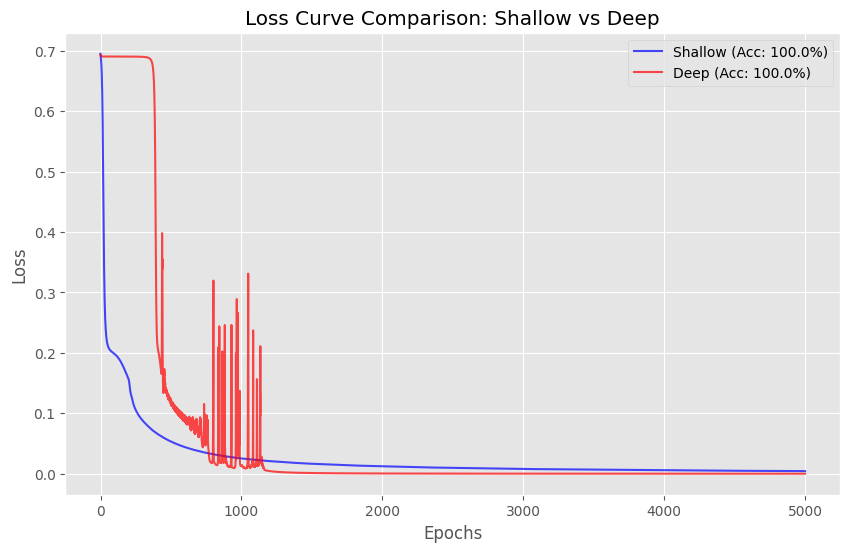

In [ ]:
EPOCHS = 5000
LEARNING_RATE = 0.5
ACTIVATION = "relu"

print("========================================")
print("실험 1 : 은닉층 1개")
print("========================================")
# 입력(2) -> 은닉(8) -> 출력(1)
dims_shallow = [X_train.shape[1], 8, 1]
params_shallow, loss_shallow, acc_shallow = train_deep_model(
    X_train, y_train, X_test, y_test, dims_shallow, EPOCHS, LEARNING_RATE, ACTIVATION
)

print("\n========================================")
print("실험 2: 은닉층 3개")
print("========================================")
# 입력(2) -> 은닉1(8) -> 은닉2(8) -> 은닉3(4) -> 출력(1)
dims_deep = [X_train.shape[1], 8, 8, 4, 1]
params_deep_model, loss_deep, acc_deep = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep, EPOCHS, LEARNING_RATE, ACTIVATION
)

# 학습 과정(Loss 감소) 시각화 비교
plt.figure(figsize=(10, 6))
plt.plot(loss_shallow, label=f"Shallow (Acc: {acc_shallow:.1f}%)", color="blue", alpha=0.7)
plt.plot(loss_deep, label=f"Deep (Acc: {acc_deep:.1f}%)", color="red", alpha=0.7)
plt.title("Loss Curve Comparison: Shallow vs Deep")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Training with Tanh

In [ ]:
def plot_decision_boundary(X, y, parameters, title, activation="relu"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_deep(grid_points, parameters, activation=activation)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1 (x1 scaled)")
    plt.ylabel("Feature 2 (x2 scaled)")

실험 3: Tanh 활성화 함수 테스트
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: default 
[default Init] Layer 1: W1 shape (2, 8), std used: 0.1000
[default Init] Layer 2: W2 shape (8, 8), std used: 0.1000
[default Init] Layer 3: W3 shape (8, 4), std used: 0.1000
[default Init] Layer 4: W4 shape (4, 1), std used: 0.1000
Epoch    0 | Loss: 0.6931 | Train Acc: 53.8%
Epoch 1000 | Loss: 0.0021 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0005 | Train Acc: 100.0%
Epoch 3000 | Loss: 0.0002 | Train Acc: 100.0%
Epoch 4000 | Loss: 0.0002 | Train Acc: 100.0%

최종 Test Accuracy: 100.00%


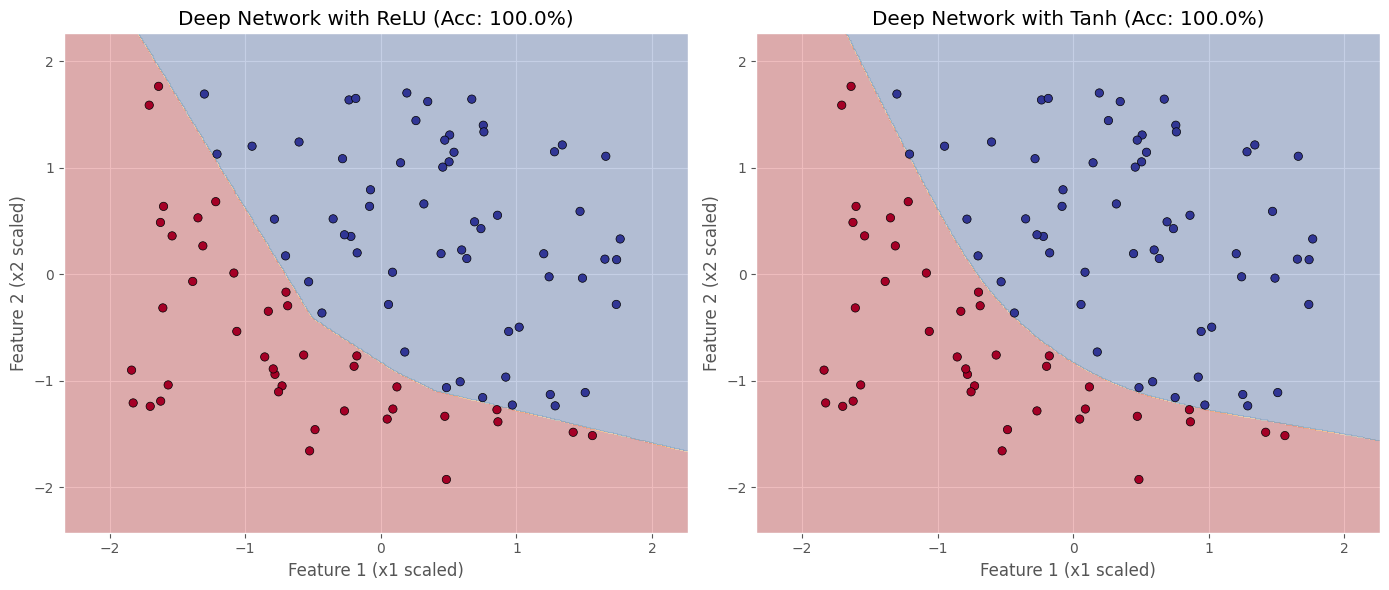

In [ ]:
print("========================================")
print("실험 3: Tanh 활성화 함수 테스트")
print("========================================")
X_all = np.vstack((X_train, X_test))
y_all = np.vstack((y_train, y_test))
dims_deep = [X_train.shape[1], 8, 8, 4, 1]

params_tanh, loss_tanh, acc_tanh = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=5000, learning_rate=0.5, activation="tanh"
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary(X_all, y_all, params_deep_model, f"Deep Network with ReLU (Acc: {acc_deep:.1f}%)", activation="relu")

plt.subplot(1, 2, 2)
plot_decision_boundary(X_all, y_all, params_tanh, f"Deep Network with Tanh (Acc: {acc_tanh:.1f}%)", activation="tanh")

plt.tight_layout()
plt.show()

## Training with various initialize way

 초기화 방식 비교 (Activation: relu)

[1] He Initialization
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: He 
[He Init] Layer 1: W1 shape (2, 8), std used: 1.0000
[He Init] Layer 2: W2 shape (8, 8), std used: 0.5000
[He Init] Layer 3: W3 shape (8, 4), std used: 0.5000
[He Init] Layer 4: W4 shape (4, 1), std used: 0.7071
Epoch    0 | Loss: 0.6951 | Train Acc: 48.8%
Epoch 1000 | Loss: 0.0008 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0002 | Train Acc: 100.0%
Epoch 3000 | Loss: 0.0001 | Train Acc: 100.0%
Epoch 4000 | Loss: 0.0001 | Train Acc: 100.0%

최종 Test Accuracy: 95.00%

[2] Xavier Initialization
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: Xavier 
[Xavier Init] Layer 1: W1 shape (2, 8), std used: 0.4472
[Xavier Init] Layer 2: W2 shape (8, 8), std used: 0.3536
[Xavier Init] Layer 3: W3 shape (8, 4), std used: 0.4082
[Xavier Init] Layer 4: W4 shape (4, 1), std used: 0.6325
Epoch    0 | Loss: 0.6935 | Train Acc: 53.8%
Epoch 1000 | Loss: 0.0011 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0002 | Train Acc: 100.0%
Epoch 

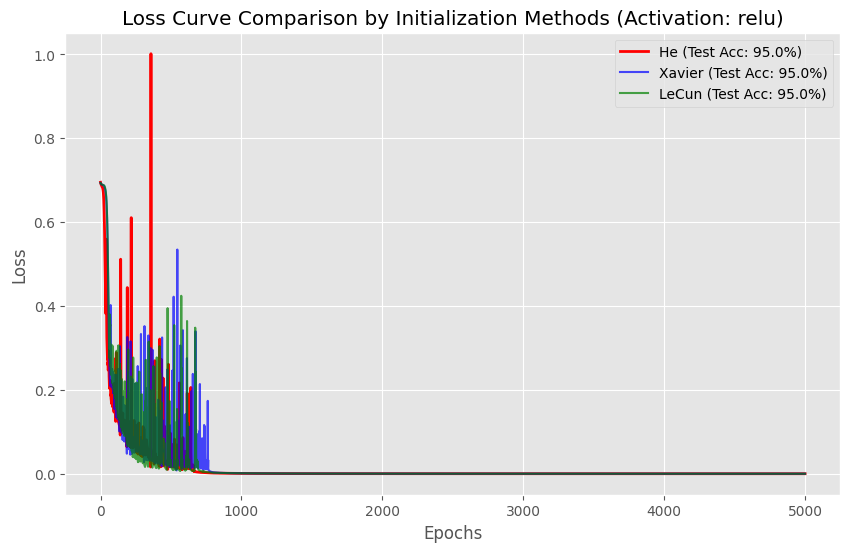

In [ ]:
EPOCHS = 5000
LEARNING_RATE = 0.5
ACTIVATION = "relu"
dims_deep = [X_train.shape[1], 8, 8, 4, 1]

print(f" 초기화 방식 비교 (Activation: {ACTIVATION})")

print("\n[1] He Initialization")
params_he, loss_he, acc_he = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="He"
)

print("\n[2] Xavier Initialization")
params_xavier, loss_xavier, acc_xavier = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="Xavier"
)

print("\n[3] LeCun Initialization")
params_lecun, loss_lecun, acc_lecun = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="LeCun"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_he, label=f"He (Test Acc: {acc_he:.1f}%)", color="red", linewidth=2)
plt.plot(loss_xavier, label=f"Xavier (Test Acc: {acc_xavier:.1f}%)", color="blue", alpha=0.7)
plt.plot(loss_lecun, label=f"LeCun (Test Acc: {acc_lecun:.1f}%)", color="green", alpha=0.7)

plt.title(f"Loss Curve Comparison by Initialization Methods (Activation: {ACTIVATION})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

 초기화 방식 비교 (Activation: tanh)

[1] He Initialization
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: He 
[He Init] Layer 1: W1 shape (2, 8), std used: 1.0000
[He Init] Layer 2: W2 shape (8, 8), std used: 0.5000
[He Init] Layer 3: W3 shape (8, 4), std used: 0.5000
[He Init] Layer 4: W4 shape (4, 1), std used: 0.7071
Epoch    0 | Loss: 0.6768 | Train Acc: 82.5%
Epoch 1000 | Loss: 0.0019 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0004 | Train Acc: 100.0%
Epoch 3000 | Loss: 0.0002 | Train Acc: 100.0%
Epoch 4000 | Loss: 0.0002 | Train Acc: 100.0%

최종 Test Accuracy: 100.00%

[2] Xavier Initialization
layer 구조: [2, 8, 8, 4, 1], 초기화 방식: Xavier 
[Xavier Init] Layer 1: W1 shape (2, 8), std used: 0.4472
[Xavier Init] Layer 2: W2 shape (8, 8), std used: 0.3536
[Xavier Init] Layer 3: W3 shape (8, 4), std used: 0.4082
[Xavier Init] Layer 4: W4 shape (4, 1), std used: 0.6325
Epoch    0 | Loss: 0.6805 | Train Acc: 83.8%
Epoch 1000 | Loss: 0.0012 | Train Acc: 100.0%
Epoch 2000 | Loss: 0.0004 | Train Acc: 100.0%
Epoch

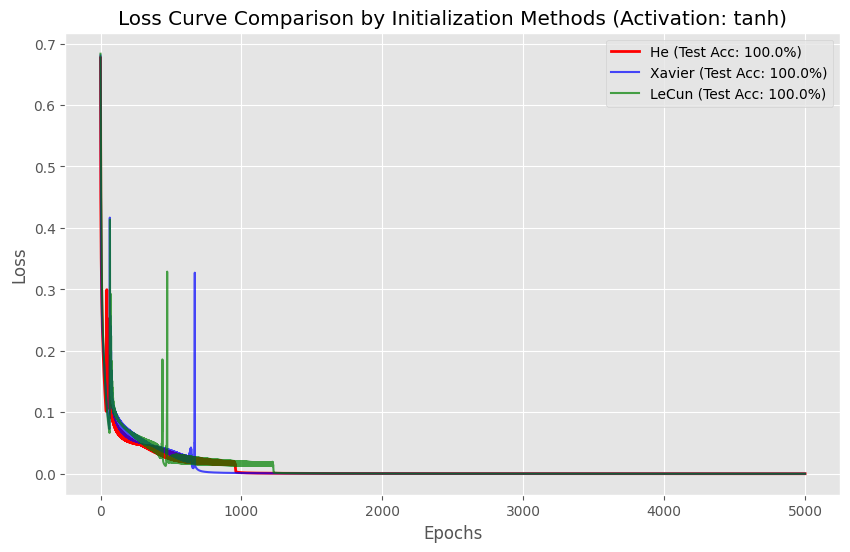

In [ ]:
EPOCHS = 5000
LEARNING_RATE = 0.5
ACTIVATION = "tanh"
dims_deep = [X_train.shape[1], 8, 8, 4, 1]

print(f" 초기화 방식 비교 (Activation: {ACTIVATION})")

print("\n[1] He Initialization")
params_he, loss_he, acc_he = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="He"
)

print("\n[2] Xavier Initialization")
params_xavier, loss_xavier, acc_xavier = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="Xavier"
)

print("\n[3] LeCun Initialization")
params_lecun, loss_lecun, acc_lecun = train_deep_model(
    X_train, y_train, X_test, y_test, dims_deep,
    epochs=EPOCHS, learning_rate=LEARNING_RATE, activation=ACTIVATION, init_way="LeCun"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_he, label=f"He (Test Acc: {acc_he:.1f}%)", color="red", linewidth=2)
plt.plot(loss_xavier, label=f"Xavier (Test Acc: {acc_xavier:.1f}%)", color="blue", alpha=0.7)
plt.plot(loss_lecun, label=f"LeCun (Test Acc: {acc_lecun:.1f}%)", color="green", alpha=0.7)

plt.title(f"Loss Curve Comparison by Initialization Methods (Activation: {ACTIVATION})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()